In [1]:
## !wget --no-check-certificate 'https://drive.google.com/uc?export=download&id=1cJyPQzVOzsCZQctNBuHCqxHnOY7v7UiA'
!pip install gdown
!pip install sympy --upgrade
!gdown https://drive.google.com/uc?id=1cJyPQzVOzsCZQctNBuHCqxHnOY7v7UiA
!pip install torchmetrics
!pip install torch-fidelity
!pip install torchmetrics[image]

  Using cached sympy-1.13.3-py3-none-any.whl.metadata (12 kB)
Using cached sympy-1.13.3-py3-none-any.whl (6.2 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1
ERROR: Operation cancelled by user
Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1cJyPQzVOzsCZQctNBuHCqxHnOY7v7UiA

but Gdown can't. Please check connections and permissions.
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import zipfile
import pathlib
from scipy.linalg import sqrtm
from torchmetrics.image.fid import FrechetInceptionDistance
import torchvision

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:
with zipfile.ZipFile("Samples.zip") as data_zip:
  data_zip.extractall()

In [3]:
class LensDataset(torch.utils.data.Dataset):
  def __init__(self, root_dir):
    self.root_dir = root_dir
    self.file_names = [f.stem for f in self.root_dir.glob("*.npy")]

  def __len__(self):
    return len(self.file_names)

  def __getitem__(self, idx):
    file_name = self.file_names[idx]
    image_path = self.root_dir / f"{file_name}.npy"

    # Load .npy files
    image = np.load(image_path).astype(np.float32)

    # Convert to PyTorch tensors
    image = torch.from_numpy(image)

    return image

In [4]:
DATASET_PATH = pathlib.Path("Samples")

lens_dataset = LensDataset(DATASET_PATH)
dataloader = torch.utils.data.DataLoader(lens_dataset, batch_size=32, shuffle=True, num_workers=4)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [6]:
def visualize_samples(dataloader, num_samples=5):
    """Visualize images from the dataloader."""
    batch = next(iter(dataloader))  # Get a batch
    images = batch  # Unpack images
    print(images[0].shape)

    fig, axes = plt.subplots(num_samples, 1, figsize=(8, num_samples * 3))

    for i in range(num_samples):
        image = images[i].permute(1, 2, 0).numpy()  # Convert to (H, W, C) for display

        axes[i].imshow(image)
        axes[i].set_title("Sample Image")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

torch.Size([1, 150, 150])


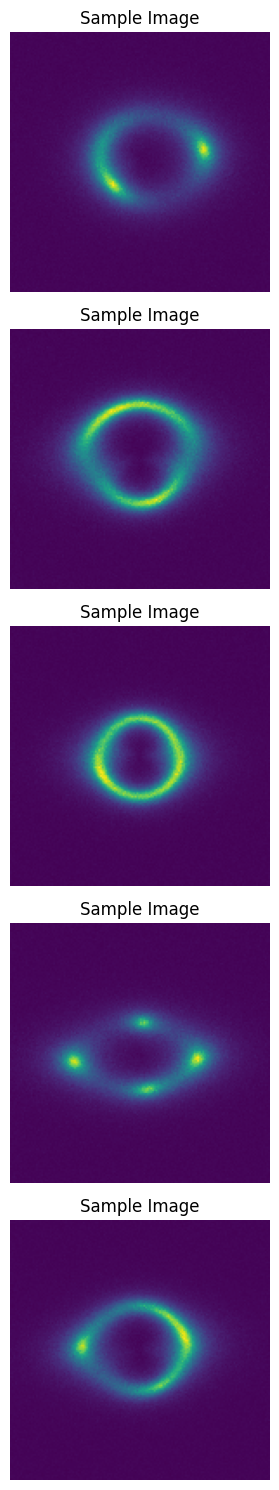

In [21]:
visualize_samples(dataloader)

In [5]:
## Forward Diffusion Class

# Define the noise schedule
def linear_beta_schedule(timesteps, start=0.0001, end=0.02):
    return torch.linspace(start, end, timesteps)

def cosine_beta_schedule(timesteps, s=0.008):
    """
    Cosine scheduler
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

# Define the forward diffusion process
class Diffusion:
    def __init__(self, timesteps=1000, beta_schedule='cosine'):
        self.timesteps = timesteps

        if beta_schedule == 'linear':
            self.betas = linear_beta_schedule(timesteps)
        elif beta_schedule == 'cosine':
            self.betas = cosine_beta_schedule(timesteps)
        else:
            raise ValueError(f"Unknown beta schedule: {beta_schedule}")

        self.betas = self.betas.to(device)
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, axis=0).to(device)
        self.alphas_cumprod_prev = torch.nn.functional.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0).to(device)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod).to(device)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod).to(device)

    def q_sample(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)

        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t].reshape(-1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1, 1, 1)

        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

    def sample_timesteps(self, n):
        return torch.randint(low=0, high=self.timesteps, size=(n,))

In [6]:
## Backward Diffusion for noise prediction

class Block(torch.nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp = torch.nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = torch.nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = torch.nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = torch.nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = torch.nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = torch.nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = torch.nn.BatchNorm2d(out_ch)
        self.bnorm2 = torch.nn.BatchNorm2d(out_ch)
        self.relu = torch.nn.ReLU()

    def forward(self, x, t):
        h = self.bnorm1(self.relu(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        h = self.bnorm2(self.relu(self.conv2(h)))
        return self.transform(h)

class SinusoidalPositionEmbeddings(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class SimpleUnet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 1  # Grayscale images
        down_channels = (64, 128, 256, 512, 1024)
        up_channels = (1024, 512, 256, 128, 64)
        out_dim = 1
        time_emb_dim = 32

        # Time embedding
        self.time_mlp = torch.nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            torch.nn.Linear(time_emb_dim, time_emb_dim),
            torch.nn.ReLU()
        )

        # Initial projection
        self.conv0 = torch.nn.Conv2d(image_channels, down_channels[0], 3, padding=1)

        # Downsample
        self.downs = torch.nn.ModuleList([
            Block(down_channels[i], down_channels[i+1], time_emb_dim)
            for i in range(len(down_channels)-1)
        ])

        # Upsample
        self.ups = torch.nn.ModuleList([
            Block(up_channels[i], up_channels[i+1], time_emb_dim, up=True)
            for i in range(len(up_channels)-1)
        ])

        self.output = torch.nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, timestep):
        # Embed time
        t = self.time_mlp(timestep)

        # Initial conv
        x = self.conv0(x)

        # Unet
        residual_inputs = []
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x)

        for up in self.ups:
            residual_x = residual_inputs.pop()
            # Ensure spatial dimensions match before concatenation
            if x.shape[2:] != residual_x.shape[2:]:
                x = torch.nn.functional.interpolate(x, size=residual_x.shape[2:], mode='bilinear', align_corners=False)
            x = torch.cat((x, residual_x), dim=1)
            x = up(x, t)

        return self.output(x)

In [7]:
def train(model, diffusion, dataloader, epochs=100, lr=2e-4):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.MSELoss()

    for epoch in range(epochs):
        pbar = tqdm(dataloader)
        for step, batch in enumerate(pbar):
            optimizer.zero_grad()

            batch = batch.to(device)

            # Sample random timesteps
            t = diffusion.sample_timesteps(batch.shape[0]).to(device)

            # Sample noise and add to images
            noise = torch.randn_like(batch)
            x_t = diffusion.q_sample(batch, t, noise)

            # Predict noise
            predicted_noise = model(x_t, t)

            # Calculate loss
            loss = criterion(noise, predicted_noise)

            # Backpropagation
            loss.backward()
            optimizer.step()

            pbar.set_description(f"Epoch {epoch} Loss: {loss.item():.4f}")

    return model

In [11]:
# Initialize model and diffusion
model = SimpleUnet()
model = model.to(device)
diffusion = Diffusion(timesteps=1000, beta_schedule='cosine')

# Train the model
trained_model = train(model, diffusion, dataloader, epochs=25)

# Save final model
torch.save(trained_model.state_dict(), "lensing_diffusion_final.pth")

Epoch 16 Loss: 0.0016:   4%|▍         | 12/313 [00:15<06:36,  1.32s/it]


KeyboardInterrupt: 

In [13]:
torch.save(model.state_dict(), "lensing_diffusion_checkpoint_15_epoch.pth")

In [8]:
fid_calculator = FrechetInceptionDistance(feature=64).to(device)

def calculate_fid(real_images, generated_images):
    real_images = real_images.to(device).type(torch.uint8)
    generated_images = generated_images.to(device).type(torch.uint8)

    # Reset internal buffers
    fid_calculator.reset()

    # Update metrics
    fid_calculator.update(real_images, real=True)
    fid_calculator.update(generated_images, real=False)

    return fid_calculator.compute()

In [9]:
model = SimpleUnet()
model = model.to(device)
diffusion = Diffusion(timesteps=1000, beta_schedule='cosine')

model.load_state_dict(torch.load("lensing_diffusion_checkpoint_15_epoch.pth", map_location=device), strict=False)
with torch.no_grad():
    # Generate samples
    generated_samples = []
    for _ in tqdm(range(1)):  # Generate in batches
        x = torch.randn((32, 1, 64, 64)).to(device)
        for i in reversed(range(diffusion.timesteps)):
            t = torch.full((32,), i, dtype=torch.long).to(device)
            predicted_noise = model(x, t)
            alpha = diffusion.alphas[t][:, None, None, None]
            alpha_cumprod = diffusion.alphas_cumprod[t][:, None, None, None]
            beta = diffusion.betas[t][:, None, None, None]
            if i > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)
            x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_cumprod))) * predicted_noise) + torch.sqrt(beta) * noise
        generated_samples.append(x)

    generated_samples = torch.cat(generated_samples)[:32]  # Take 1000 samples
    generated_samples = (generated_samples.clamp(-1, 1) + 1) / 2

    # Get real samples
    real_samples = torch.stack([lens_dataset[i] for i in range(32)]).to(device)

    # Convert to 3-channel format expected by FID
    real_samples = real_samples.repeat(1, 3, 1, 1)
    generated_samples = generated_samples.repeat(1, 3, 1, 1)

    # Calculate FID
    fid_score = calculate_fid(real_samples, generated_samples)
    print(f"FID Score: {fid_score.item()}")

100%|██████████| 1/1 [01:17<00:00, 77.11s/it]

FID Score: 0.04109262675046921
